In [1]:
import os
from typing import Tuple

import torch
from torch.utils.data import DataLoader

from train_croma_so2sat import So2SatLCZ42Dataset, CromaLCZClassifier


@torch.no_grad()
def evaluate_confusion_and_f1(
    model: torch.nn.Module,
    dataloader: DataLoader,
    device: str,
    num_classes: int = 10,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, float]:
    """Compute confusion matrix and per-class precision/recall/F1 and accuracy.

    Args:
        model: Trained model in eval mode.
        dataloader: DataLoader over the test set.
        device: Device string ("cuda" or "cpu").
        num_classes: Number of classes.

    Returns:
        confusion: Tensor of shape (num_classes, num_classes),
                   confusion[i, j] = count of true=i, pred=j.
        precision: Tensor (num_classes,), per-class precision.
        recall: Tensor (num_classes,), per-class recall.
        f1: Tensor (num_classes,), per-class F1 score.
        accuracy: Scalar float, global accuracy.
    """
    model.eval()
    confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)

    for sar, optical, labels in dataloader:
        sar = sar.to(device, non_blocking=True)
        optical = optical.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(sar, optical)
        preds = torch.argmax(logits, dim=1)

        # Vectorized confusion update: no Python loop over samples
        indices = labels * num_classes + preds
        binc = torch.bincount(
            indices,
            minlength=num_classes * num_classes,
        ).reshape(num_classes, num_classes)

        confusion += binc.cpu()

    tp = torch.diag(confusion).float()
    per_class_pred = confusion.sum(dim=0).float()
    per_class_true = confusion.sum(dim=1).float()

    precision = tp / (per_class_pred + 1e-12)
    recall = tp / (per_class_true + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    total_correct = tp.sum().item()
    total_samples = confusion.sum().item()
    accuracy = total_correct / total_samples if total_samples > 0 else 0.0

    return confusion, precision, recall, f1, accuracy


In [2]:
test_h5 = "/media/stagiaire/T7/LCZ42/testing.h5"
croma_weights = "./CROMA_base.pt"  
finetuned_model_path = "./croma_lcz42_best_f1_macro.pth"

img_res = 120
batch_size = 64
num_workers = 4
num_classes = 10

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running evaluation on device: {device}")

# Dataset: urban-only (classes 0..9)
test_dataset = So2SatLCZ42Dataset(
    test_h5,
    image_resolution=img_res,
    normalize=True,
    use_8_bit=True,
    urban_only=True,
)

print(f"Test samples (urban-only): {len(test_dataset)}")

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)

# Rebuild the model exactly like in training
model = CromaLCZClassifier(
    pretrained_path=croma_weights,
    num_classes=num_classes,
    size="base",
    image_resolution=img_res,
    device=device,
    modality="both",
).to(device)

# Load fine-tuned weights (full state_dict)
state = torch.load(finetuned_model_path, map_location=device)
model.load_state_dict(state)
model.eval()


Running evaluation on device: cuda
Test samples (urban-only): 14469
Initializing SAR encoder
Initializing optical encoder
Initializing joint SAR-optical encoder


CromaLCZClassifier(
  (backbone): PretrainedCROMA(
    (s1_encoder): ViT(
      (linear_input): Linear(in_features=128, out_features=768, bias=True)
      (transformer): BaseTransformer(
        (layers): ModuleList(
          (0-5): 6 x ModuleList(
            (0): Attention(
              (to_qkv): Linear(in_features=768, out_features=2304, bias=False)
              (to_out): Linear(in_features=768, out_features=768, bias=True)
              (input_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (1): FFN(
              (net): Sequential(
                (0): Linear(in_features=768, out_features=3072, bias=True)
                (1): GELU(approximate='none')
                (2): Dropout(p=0.0, inplace=False)
                (3): Linear(in_features=3072, out_features=768, bias=True)
              )
              (input_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            )
 

In [3]:
confusion, precision, recall, f1, accuracy = evaluate_confusion_and_f1(
    model,
    test_loader,
    device=device,
    num_classes=num_classes,
)

print("=== Global metrics on test set (urban 10 classes) ===")
print(f"Accuracy: {accuracy:.4f}")

print("\n=== Confusion matrix (rows=true, cols=pred) ===")
print(confusion.numpy())

print("\n=== Per-class metrics (class indices 0..9) ===")
for c in range(num_classes):
    support = int(confusion[c].sum().item())
    print(
        f"Class {c:2d}: "
        f"precision={precision[c]:.4f} "
        f"recall={recall[c]:.4f} "
        f"f1={f1[c]:.4f} "
        f"(support={support})"
    )

=== Global metrics on test set (urban 10 classes) ===
Accuracy: 0.6844

=== Confusion matrix (rows=true, cols=pred) ===
[[ 138   22    7   67    5    1    0    8    0   18]
 [  34  903  121   14   80   11   27   62    1    9]
 [   5  251 1853    4   46  180   97   19    4    6]
 [  31   45    5  681   41    4    0   21    1   28]
 [   4   50   54  157  390   76    2   14    7    9]
 [   2   14  327    7  111 1197    3   53  190   32]
 [   0   57  230    2    6    0  170   22    3   13]
 [  42   93   54   23   32   14    4 2890   15  329]
 [   0    2   60    4   38  619    8   77 1151   54]
 [   4   17   10    3   27   12    0  277   29  529]]

=== Per-class metrics (class indices 0..9) ===
Class  0: precision=0.5308 recall=0.5188 f1=0.5247 (support=266)
Class  1: precision=0.6210 recall=0.7155 f1=0.6649 (support=1262)
Class  2: precision=0.6810 recall=0.7517 f1=0.7146 (support=2465)
Class  3: precision=0.7079 recall=0.7946 f1=0.7488 (support=857)
Class  4: precision=0.5026 recall=0.511

In [7]:
import numpy as np

conf = confusion.numpy().astype(float)

row_sums = conf.sum(axis=1, keepdims=True) + 1e-12
conf_percent = (conf / row_sums) * 100.0

print("=== Confusion matrix (%), rows = true, cols = predicted ===\n")
print(np.round(conf_percent, 1))

=== Confusion matrix (%), rows = true, cols = predicted ===

[[51.9  8.3  2.6 25.2  1.9  0.4  0.   3.   0.   6.8]
 [ 2.7 71.6  9.6  1.1  6.3  0.9  2.1  4.9  0.1  0.7]
 [ 0.2 10.2 75.2  0.2  1.9  7.3  3.9  0.8  0.2  0.2]
 [ 3.6  5.3  0.6 79.5  4.8  0.5  0.   2.5  0.1  3.3]
 [ 0.5  6.6  7.1 20.6 51.1 10.   0.3  1.8  0.9  1.2]
 [ 0.1  0.7 16.9  0.4  5.7 61.8  0.2  2.7  9.8  1.7]
 [ 0.  11.3 45.7  0.4  1.2  0.  33.8  4.4  0.6  2.6]
 [ 1.2  2.7  1.5  0.7  0.9  0.4  0.1 82.7  0.4  9.4]
 [ 0.   0.1  3.   0.2  1.9 30.8  0.4  3.8 57.2  2.7]
 [ 0.4  1.9  1.1  0.3  3.   1.3  0.  30.5  3.2 58.3]]


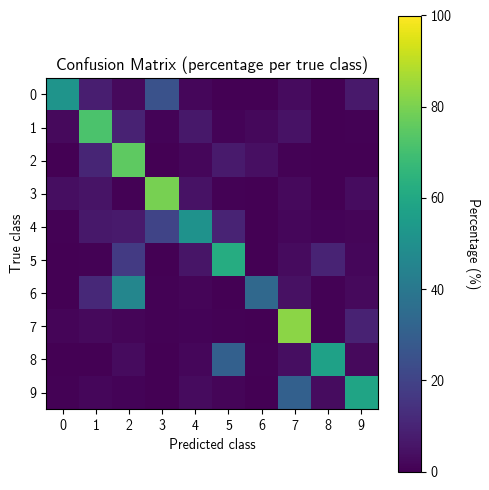

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager 

font_path = "/usr/share/fonts/truetype/cmu/cmunss.ttf" 
font_manager.fontManager.addfont(font_path)
font_prop = font_manager.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()

df_percent = pd.DataFrame(
    np.round(conf_percent, 2),
    index=[f"True_{i}" for i in range(num_classes)],
    columns=[f"Pred_{i}" for i in range(num_classes)],
)

df_percent

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(conf_percent, cmap="viridis", vmin=0, vmax=100)

cbar = ax.figure.colorbar(im, ax=ax)
cbar.set_label("Percentage (%)", rotation=270, labelpad=20)

ax.set_title("Confusion Matrix (percentage per true class)")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")

ticks = np.arange(num_classes)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

plt.tight_layout()
plt.show()
